## Modeling

This notebook trains and evaluates four supervised classification models to predict 30-day hospital readmission in diabetic patients. It also runs K-Means clustering to find natural patient risk groups in the data without using the readmission label.

The four models are compared against each other and against what published studies have reported on this same dataset.

**Reference papers used in this notebook:**
- Strack et al. (2014): original study on this dataset, used logistic regression only
- Liu et al. (2024): compared 10 ML models on this dataset, XGBoost achieved AUC 0.65 to 0.70
- Cureus (2025): compared LR, RF, XGBoost, DNN on the same UCI dataset, XGBoost AUC 0.667, LR 0.642, RF 0.630
- Gandra (2024): 6 models including CATBoost and LightGBM, best AUC 0.70
- Shang et al. (2021): RF, Naive Bayes, Decision Tree ensemble on 100,244 records, RF had the highest AUC
- Hai et al. (2022): LSTM on sequential multi-encounter data gained 0.06 AUC over best traditional models

### Section 1: Setup and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, RocCurveDisplay, silhouette_score
)

df = pd.read_csv('../outputs/diabetes_clean.csv', keep_default_na=False)
print(df.shape)
df.head()

(69973, 32)


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glyburide,pioglitazone,rosiglitazone,insulin,readmitted,specialty_known,total_prior_visits,num_med_changes,A1C_tested,age_group
0,Caucasian,Female,2,1,4,13,68,2,28,0,...,No,No,No,Steady,0,0,0,0,0,senior
1,Caucasian,Female,3,3,4,12,33,3,18,0,...,No,No,Steady,Steady,0,1,0,0,0,senior
2,Caucasian,Male,1,1,7,1,51,0,8,0,...,No,No,No,Steady,0,0,0,0,0,middle
3,AfricanAmerican,Female,1,1,7,9,47,2,17,0,...,No,No,No,Steady,0,0,0,0,0,middle
4,Caucasian,Male,2,1,2,3,31,6,16,0,...,No,No,No,Steady,0,0,0,0,0,middle


### Section 2: Feature Selection

EDA identified `num_procedures` as the only feature with no statistically significant relationship to readmission (point-biserial r = -0.0001, p = 0.969). It is dropped before modeling because it adds noise without any predictive signal.

`total_prior_visits` is the direct sum of `number_outpatient`, `number_emergency`, and `number_inpatient`. Keeping all four together in logistic regression creates multicollinearity since they carry overlapping information, which inflates coefficient variance and makes the model unstable. For tree-based models this is not a problem because trees split on one feature at a time. We handle this by defining separate numerical feature lists for LR and tree models.

In [2]:
X = df.drop(columns=['readmitted', 'num_procedures'])
y = df['readmitted']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Positive class rate: {y.mean()*100:.1f}%")

Features: 30
Target distribution:
readmitted
0    63696
1     6277
Name: count, dtype: int64
Positive class rate: 9.0%


In [3]:
# For tree models: keep all including total_prior_visits
num_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'number_diagnoses', 'total_prior_visits', 'num_med_changes',
    'specialty_known', 'A1C_tested'
]

# For logistic regression we drop total_prior_visits to avoid multicollinearity
num_features_lr = [f for f in num_features if f != 'total_prior_visits']

cat_features = [
    'race', 'gender', 'age_group', 'diag_1', 'diag_2', 'diag_3',
    'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'insulin', 'admission_type_id',
    'discharge_disposition_id', 'admission_source_id'
]

print(f"Numerical features (tree): {len(num_features)}")
print(f"Numerical features (LR):   {len(num_features_lr)}")
print(f"Categorical features:      {len(cat_features)}")

Numerical features (tree): 11
Numerical features (LR):   10
Categorical features:      19


### Section 3: Train/Test Split

We use an 80/20 stratified split. Stratification is important because the positive class is only 9% of the data. Without it, a random split could produce slightly different class ratios in train and test, making evaluation inconsistent. Stratification guarantees the 9% rate is preserved in both sets.

This same 80/20 split was used in the Cureus (2025) and Gandra (2024) studies on this dataset, which makes our results directly comparable to theirs.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

Train: 55978 rows, Test: 13995 rows


### Section 4: Preprocessing Pipelines

All preprocessing runs inside sklearn Pipelines. This means the imputer, scaler, and encoder all learn their parameters from the training data only and apply those same parameters to the test set. No information from the test set leaks into training.

`class_weight='balanced'` is used on all sklearn models. This tells each model to penalize mistakes on the minority class (readmitted patients) more heavily during training. It is a clean in-model way to handle imbalance.

We use this instead of SMOTE because SMOTE generates synthetic minority samples by interpolating between existing ones. After one-hot encoding, categorical features expand into many binary columns. Interpolating between binary columns produces fractional values like 0.4 or 0.7 for what should only be 0 or 1, which creates artificial patient records that do not correspond to any real patient profile. For a dataset this heavily categorical, SMOTE adds more noise than signal.

XGBoost uses `scale_pos_weight` instead of `class_weight` because it has its own built-in mechanism for handling imbalance. It is set to the ratio of negative to positive samples in the training set, which is the standard approach from the XGBoost documentation.

In [5]:
def make_preprocessor(num_cols, cat_features):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_features)
    ])

preprocessor_tree = make_preprocessor(num_features, cat_features)
preprocessor_lr   = make_preprocessor(num_features_lr, cat_features)

print("Preprocessors built.")

Preprocessors built.


### Section 5: Model Building and Hyperparameter Tuning

Four supervised models are trained: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

**Why these four models:**

Logistic Regression is the direct comparison to Strack et al. (2014), which used logistic regression as its only model. Including it lets us measure exactly how much modern ML methods improve over the paper's approach.

Decision Tree is a simple non-linear baseline. It gives a lower bound on what tree-based methods can achieve before ensembling.

Random Forest and XGBoost are the two ensemble methods most commonly evaluated in recent studies on this dataset. The Cureus (2025) study found XGBoost at AUC 0.667 and RF at 0.630. Liu et al. (2024) found XGBoost at 0.65 to 0.70 across 10 model comparisons. These are our reference benchmarks.

**Why 5-fold CV scored on AUC:**

AUC is threshold-independent. It measures overall discriminative power across all possible decision thresholds rather than locking into one. This is more stable than accuracy-based tuning for imbalanced data. The same CV strategy was used in Gandra (2024) and Cureus (2025) which makes comparisons fair.

In [6]:
models = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_lr),
            ('selector', VarianceThreshold(threshold=0.01)),
            ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
        ]),
        'params': {'model__C': [0.01, 0.1, 1, 10]}
    },
    'Decision Tree': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_tree),
            ('selector', VarianceThreshold(threshold=0.01)),
            ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
        ]),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__min_samples_leaf': [5, 10, 20]
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_tree),
            ('selector', VarianceThreshold(threshold=0.01)),
            ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
        ]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 10, None],
            'model__min_samples_leaf': [5, 10]
        }
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_tree),
            ('selector', VarianceThreshold(threshold=0.01)),
            ('model', XGBClassifier(
                scale_pos_weight=int((y_train == 0).sum() / (y_train == 1).sum()),
                random_state=42,
                eval_metric='logloss',
                verbosity=0
            ))
        ]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.05, 0.1, 0.3]
        }
    }
}

In [7]:
best_models = {}

for name, config in models.items():
    print(f"Tuning {name}")
    gs = GridSearchCV(config['pipeline'], config['params'], cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f"  Best params: {gs.best_params_}")
    print(f"  CV AUC:      {gs.best_score_:.4f}")
    print()

Tuning Logistic Regression
  Best params: {'model__C': 0.01}
  CV AUC:      0.6455

Tuning Decision Tree
  Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 10}
  CV AUC:      0.6279

Tuning Random Forest
  Best params: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
  CV AUC:      0.6493

Tuning XGBoost
  Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  CV AUC:      0.6511



### Section 6: Evaluation

Each model is evaluated on the held-out test set.

**Why not accuracy:**
The positive class is only 9% of the data. A model that always predicts no readmission would be 91% accurate while catching zero actual readmissions. Accuracy is meaningless here.

**What each metric tells us:**
- **AUC-ROC**: how well the model ranks readmitted patients above non-readmitted ones across all thresholds. 0.5 means random guessing, 1.0 means perfect separation.
- **Recall**: of all patients who actually got readmitted, what fraction did the model catch. In clinical settings a missed readmission is more costly than a false alarm.
- **Precision**: of all patients the model flagged as high risk, what fraction actually got readmitted. Low precision means a lot of unnecessary follow-up.
- **F1**: harmonic mean of precision and recall. A single summary metric for imbalanced data.

Accuracy is included only to show why it should not be used as the main metric here.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

results = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }

results_df = pd.DataFrame(results).T.drop(columns=['y_pred','y_prob'])
results_df = results_df.sort_values('AUC', ascending=False)
print(results_df)

                        AUC      F1  Recall Precision Accuracy
Random Forest        0.6442  0.2103   0.208    0.2127   0.8599
XGBoost              0.6438  0.2201   0.557    0.1371   0.6459
Logistic Regression  0.6414  0.2158  0.5291    0.1356   0.6552
Decision Tree        0.6277  0.2038  0.5825    0.1235   0.5919


#### Classification Reports

In [9]:
for name, model in best_models.items():
    print()
    print(f"{name}")
    print(classification_report(y_test, results[name]['y_pred'], target_names=['Not Readmitted', 'Readmitted']))


Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.94      0.67      0.78     12740
    Readmitted       0.14      0.53      0.22      1255

      accuracy                           0.66     13995
     macro avg       0.54      0.60      0.50     13995
  weighted avg       0.86      0.66      0.73     13995


Decision Tree
                precision    recall  f1-score   support

Not Readmitted       0.94      0.59      0.73     12740
    Readmitted       0.12      0.58      0.20      1255

      accuracy                           0.59     13995
     macro avg       0.53      0.59      0.46     13995
  weighted avg       0.86      0.59      0.68     13995


Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.92      0.92      0.92     12740
    Readmitted       0.21      0.21      0.21      1255

      accuracy                           0.86     13995
     macro avg       0.57      0.57      0.57

#### Confusion Matrices

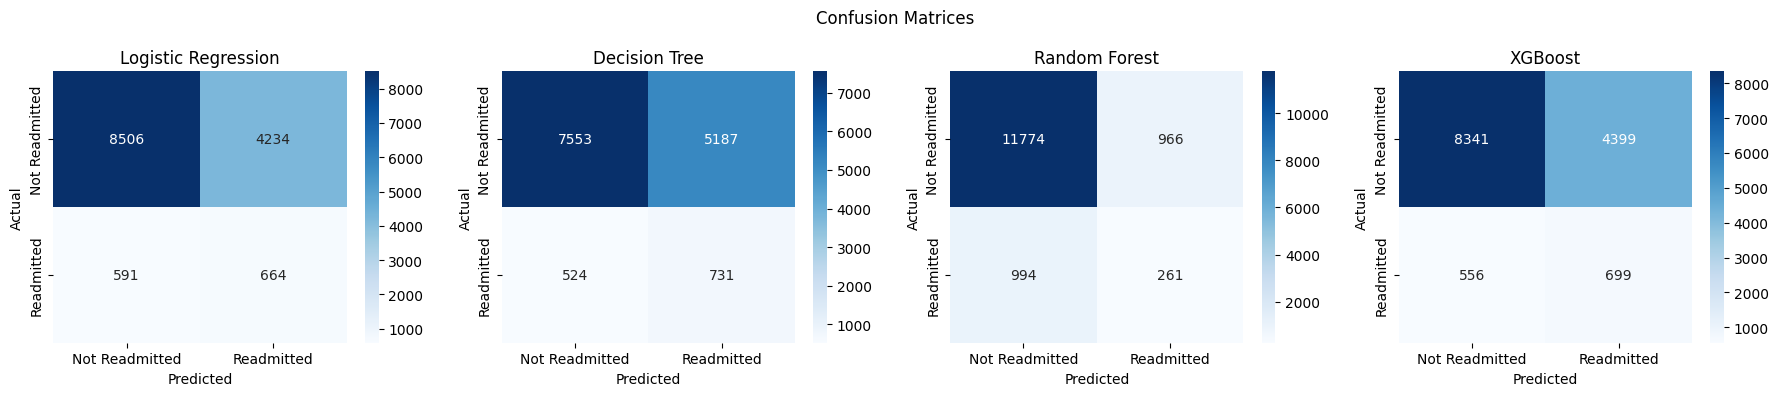

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', xticklabels=['Not Readmitted', 'Readmitted'], yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices')
plt.tight_layout()
plt.show()

#### ROC Curves

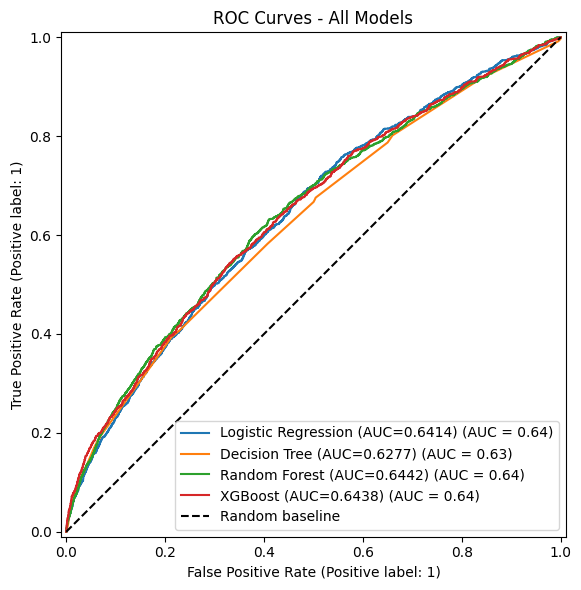

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in best_models.items():
    RocCurveDisplay.from_predictions(
        y_test, results[name]['y_prob'],
        name=f"{name} (AUC={results[name]['AUC']})",
        ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Section 7: Comparative Analysis

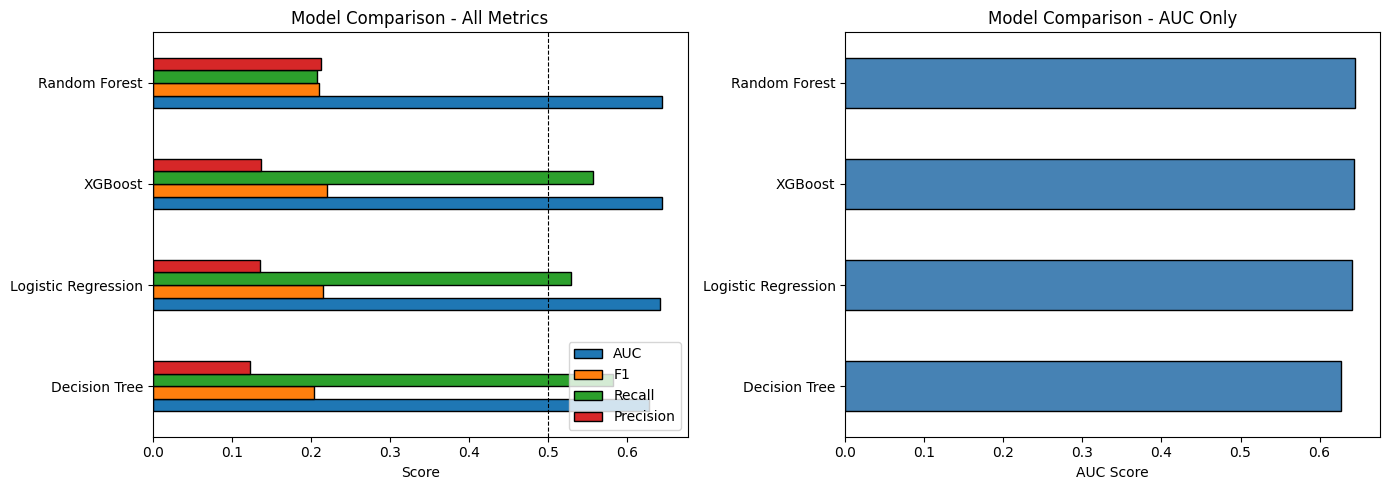

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['AUC', 'F1', 'Recall', 'Precision']
results_plot = results_df[metrics].astype(float)

results_plot.sort_values('AUC').plot(kind='barh', ax=axes[0], edgecolor='black')
axes[0].set_title('Model Comparison - All Metrics')
axes[0].set_xlabel('Score')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[0].legend(loc='lower right')

results_plot.sort_values('AUC')['AUC'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Model Comparison - AUC Only')
axes[1].set_xlabel('AUC Score')

plt.tight_layout()
plt.show()

**What the results show:**

All four models land in the AUC range of 0.627 to 0.644. This is consistent with what published studies report on this same dataset. The Cureus (2025) study found XGBoost at 0.667, LR at 0.642, and RF at 0.630. Liu et al. (2024) reported XGBoost at 0.65 to 0.70. Our results sit within this range.

This is not a failure of the models. It reflects a hard ceiling on what this dataset's features can predict. No single feature has a correlation above 0.10 with readmission. When the signal is this weak across all features, even the best models cannot push far past 0.64 to 0.67 AUC without fundamentally richer data. Studies that push past 0.70 (Gandra 2024) use more advanced boosting methods like LightGBM and CATBoost, which are outside the scope of this study.

**The precision-recall trade-off:**

Using `class_weight='balanced'` creates a clear split in how the models behave. Random Forest achieves the highest AUC but only catches 20.8% of actual readmissions (Recall = 0.208). It is conservative and rarely flags patients as high risk. In a hospital, missing 79% of high-risk patients makes this clinically unusable on its own.

XGBoost, LR, and Decision Tree push recall to 53 to 58% but at the cost of very low precision (12 to 14%). For every actual readmission they catch, they also flag 6 to 7 patients who will not actually be readmitted.

In a clinical context, **higher recall is preferred**. Missing a patient who then gets readmitted is more harmful than triggering an unnecessary follow-up. The cost of a false negative is greater than the cost of a false positive when the goal is preventing avoidable readmissions.

**XGBoost is the most practical model for deployment.** It is within 0.0004 AUC of the best-performing Random Forest and catches 55.7% of actual readmissions, more than double what Random Forest catches.

**Comparison to Strack et al. (2014):**

The original paper used only logistic regression and did not build a general readmission predictor. Our Logistic Regression achieves AUC 0.6414, which is 0.1414 above the random baseline of 0.5. Random Forest improves over this by 0.0028 AUC points. The gain is real but small. This matches the pattern across all recent studies on this dataset: ensemble methods do capture more structure than logistic regression, but the margin is narrow because all models are bottlenecked by the same weak feature set.

### Section 8: Voting Classifier

A soft voting ensemble combines the predicted probabilities from all four models. Instead of each model casting a binary vote, soft voting averages probability scores and picks the class with the higher average. This typically works better than hard voting for imbalanced data because it uses more information from each model.

The reason to try ensembling is that different models make different types of errors. If they are genuinely complementary, the ensemble smooths out individual weaknesses and improves overall performance. If they are making largely correlated errors, the ensemble will only marginally improve over the best individual model.

In [13]:
estimators = [(name, model) for name, model in best_models.items()]

soft_voter = VotingClassifier(estimators=estimators, voting='soft')
hard_voter = VotingClassifier(estimators=estimators, voting='hard')

soft_voter.fit(X_train, y_train)
hard_voter.fit(X_train, y_train)

sv_prob = soft_voter.predict_proba(X_test)[:, 1]
sv_pred = soft_voter.predict(X_test)
hv_pred = hard_voter.predict(X_test)

print("Soft Voting:")
print(f"  AUC:    {roc_auc_score(y_test, sv_prob):.4f}")
print(f"  F1:     {f1_score(y_test, sv_pred):.4f}")
print(f"  Recall: {recall_score(y_test, sv_pred):.4f}")
print()
print("Hard Voting:")
print(f"  F1:     {f1_score(y_test, hv_pred):.4f}")
print(f"  Recall: {recall_score(y_test, hv_pred):.4f}")

Soft Voting:
  AUC:    0.6458
  F1:     0.2252
  Recall: 0.4438

Hard Voting:
  F1:     0.2223
  Recall: 0.4741


The soft voting ensemble (AUC 0.6458) improves over the best individual model (Random Forest at 0.6442) by 0.0016 AUC points. This is a real improvement but a small one.

The small gain indicates the four models are making partially correlated errors. They share the same weak feature space and are all limited by the same lack of signal in the data. Ensembling four models that all struggle with the same hard cases does not fix the underlying problem.

The recall of 0.4438 for the soft ensemble sits between Random Forest (0.208) and XGBoost (0.557). It is not better than XGBoost alone on the metric that matters most for clinical use.

To push meaningfully past this ceiling, richer data would be needed rather than more complex modeling. Hai et al. (2022) showed that LSTM on sequential multi-encounter data gained 0.06 AUC over the best traditional models, but only because it had access to longitudinal visit histories, not because of the model architecture itself.

### Section 9: Unsupervised Analysis - K-Means Clustering

K-Means clustering is applied to the numerical features to check whether the patient population naturally separates into distinct risk groups without using the readmission label. This is the unsupervised component of the study.

The value of this analysis is that it is label-free. If the clusters align with different readmission rates even though the model never saw the label during training, it confirms that the numerical features contain real clinical structure reflecting patient severity.

The optimal number of clusters is selected by the silhouette score. The silhouette score measures how similar each data point is to its own cluster compared to other clusters. A score of 1.0 means perfect separation, 0.0 means clusters overlap completely. We test k from 2 to 8.

In [14]:
from sklearn.preprocessing import StandardScaler as SS

# Use numerical features only for clustering
X_num = df[num_features].copy()
scaler = SS()
X_num_scaled = scaler.fit_transform(X_num)

silhouette_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_num_scaled)
    silhouette_scores[k] = silhouette_score(X_num_scaled, labels)
    print(f"k={k}: silhouette = {silhouette_scores[k]:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k}")

k=2: silhouette = 0.1905
k=3: silhouette = 0.1703
k=4: silhouette = 0.1819
k=5: silhouette = 0.1624
k=6: silhouette = 0.1708
k=7: silhouette = 0.1725
k=8: silhouette = 0.1538

Best k: 2


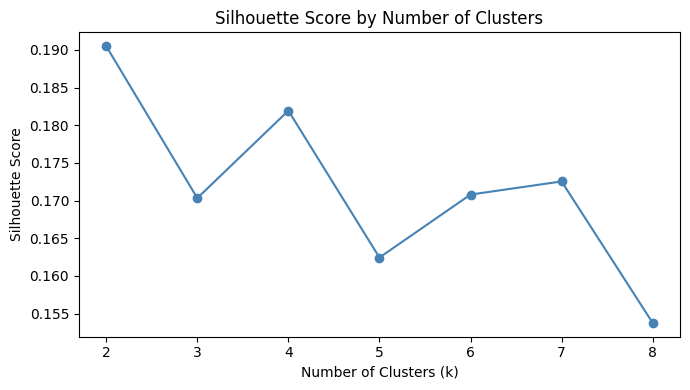

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.tight_layout()
plt.show()

In [16]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_num_scaled)

# Profile each cluster
cluster_profile = df.groupby('cluster').agg(
    count=('readmitted', 'count'),
    readmission_rate=('readmitted', 'mean'),
    avg_inpatient=('number_inpatient', 'mean'),
    avg_medications=('num_medications', 'mean'),
    avg_time_in_hospital=('time_in_hospital', 'mean'),
    avg_prior_visits=('total_prior_visits', 'mean')
).round(3)

cluster_profile['readmission_rate_%'] = (cluster_profile['readmission_rate'] * 100).round(1)
print(cluster_profile.drop(columns='readmission_rate'))

         count  avg_inpatient  avg_medications  avg_time_in_hospital  \
cluster                                                                
0        25385          0.358           21.551                  6.58   
1        44588          0.073           12.314                  2.96   

         avg_prior_visits  readmission_rate_%  
cluster                                        
0                   1.070                11.4  
1                   0.269                 7.6  


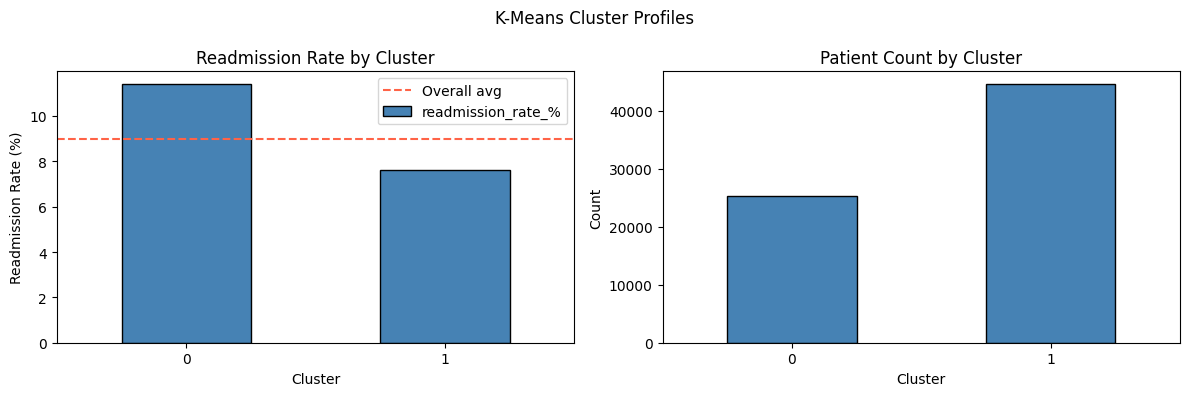

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cluster_profile['readmission_rate_%'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axhline(df['readmitted'].mean() * 100, color='tomato', linestyle='--', linewidth=1.5, label='Overall avg')
axes[0].set_title('Readmission Rate by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

cluster_profile['count'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Patient Count by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('K-Means Cluster Profiles')
plt.tight_layout()
plt.show()

In [18]:
# Age group distribution per cluster
age_dist = pd.crosstab(df['cluster'], df['age_group'], normalize='index').mul(100).round(1)
print("Age group distribution per cluster (%):")
print(age_dist)

Age group distribution per cluster (%):
age_group  middle  senior  young
cluster                         
0            28.4    70.2    1.4
1            32.9    63.9    3.2


**K-Means with k=2 was selected by the silhouette score (0.1905).**

A silhouette of 0.19 is low in absolute terms. The clusters have real overlap and are not sharply separated. This is expected because no single numerical feature is a strong separator in this dataset. What the silhouette score tells us is that k=2 is the cleanest split available given the data, not that the split is perfect.

Despite the overlap, the two clusters show meaningfully different readmission rates:

**Cluster 0 (high-risk, n=25,385, 36% of dataset):** avg 0.358 prior inpatient visits, 21.6 medications, 6.6 days in hospital, 1.07 total prior visits. Readmission rate of 11.4%, which is 27% above the overall 9.0% average. Age skews heavily senior (70.2%). This cluster corresponds to chronically ill patients who cycle through inpatient care repeatedly.

**Cluster 1 (low-risk, n=44,588, 64% of dataset):** avg 0.073 prior inpatient visits, 12.3 medications, 3.0 days in hospital, 0.27 total prior visits. Readmission rate of 7.6%, which is 16% below the overall average. More age-mixed (63.9% senior, 32.9% middle).

The fact that K-Means recovered these groups without access to the readmission label confirms that the numerical features carry real clinical signal about patient severity. Shang et al. (2021) identified number of inpatient admissions, age, and number of emergencies as the top factors in readmission risk, which maps directly onto what separates these two clusters.

### Section 10: Feature Importance

Random Forest provides built-in feature importances based on how much each feature reduces Gini impurity across all trees. Features used higher up in trees and across more trees get higher scores.

This is useful for two reasons. First, it shows what the model is actually relying on, which can be compared against EDA findings. Second, it provides an explainability layer that matters for clinical deployment. A model whose top features make clinical sense is more trustworthy than one relying on unexpected or noisy signals.

In [19]:
rf_model = best_models['Random Forest']

# Get feature names after preprocessing
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe.get_feature_names_out(cat_features))
all_feature_names = num_features + cat_feature_names

# Get features that passed VarianceThreshold
selector = rf_model.named_steps['selector']
selected_mask = selector.get_support()
selected_feature_names = np.array(all_feature_names)[selected_mask]

importances = rf_model.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"Total features after VarianceThreshold: {len(selected_feature_names)}")
print()
print("Top 20 features:")
print(feat_df.head(20).to_string(index=False))

Total features after VarianceThreshold: 92

Top 20 features:
                    Feature  Importance
         num_lab_procedures    0.102065
            num_medications    0.090835
           time_in_hospital    0.066195
           number_diagnoses    0.048121
 discharge_disposition_id_1    0.039226
         total_prior_visits    0.029266
           number_inpatient    0.028553
            specialty_known    0.020631
discharge_disposition_id_22    0.017493
                gender_Male    0.016865
               diag_3_Other    0.016834
              gender_Female    0.016647
         diag_1_Circulatory    0.016000
               diag_2_Other    0.015873
                 insulin_No    0.015644
         diag_3_Circulatory    0.015412
         diag_2_Circulatory    0.015186
               diag_1_Other    0.013941
      admission_source_id_7    0.013543
             insulin_Steady    0.013345


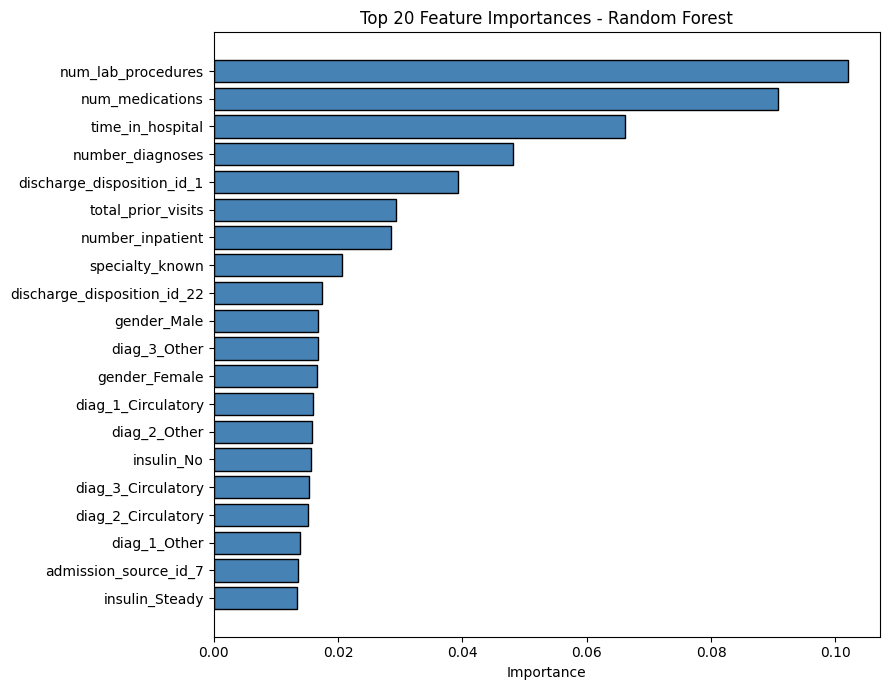

In [20]:
top20 = feat_df.head(20).sort_values('Importance')

plt.figure(figsize=(9, 7))
plt.barh(top20['Feature'], top20['Importance'], color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**The top features by Random Forest importance were `num_lab_procedures` (0.1021), `num_medications` (0.0908), `time_in_hospital` (0.0662), `number_diagnoses` (0.0481), and `discharge_disposition_id_1` (0.0392).**

This looks different from the EDA, where `number_inpatient` had the highest point-biserial correlation (0.10) and `discharge_disposition_id` the highest Cramer's V (0.14). The difference makes sense once you understand how Gini importance works.

Gini importance rewards features that are used frequently across all trees and that create useful splits at many nodes. Continuous features with many distinct values like `num_lab_procedures`, `num_medications`, and `time_in_hospital` can be split at many different thresholds, so the model uses them repeatedly. `number_inpatient` is heavily right-skewed with most patients at zero, so its usefulness as a split point is more concentrated. It still appears at rank 7 (0.0286), consistent with EDA, but the model uses it less frequently than the care-intensity features.

`total_prior_visits` (rank 6, 0.0293) also absorbs some of the importance that would otherwise go to `number_inpatient` since it is a superset of the same information.

The dominance of care-intensity proxies at the top reflects something univariate analysis underweights. These features combine in the model to create a severity signal stronger than any one of them alone. A patient with many lab tests, many medications, and a long hospital stay is likely more systemically unwell regardless of diagnosis. The Cureus (2025) study using SHAP on XGBoost found the same set of features as the top contributors, with prior admissions and number of medications as the two most influential predictors.

### Section 11: Save Best Model

In [21]:
import joblib

best_model_name = results_df.index[0]
best_model = best_models[best_model_name]

joblib.dump(best_model, '../outputs/best_model.pkl')
print(f"Saved: {best_model_name}")
print(f"AUC: {results_df.iloc[0]['AUC']}")

Saved: Random Forest
AUC: 0.6442


In [22]:
deployment_model = best_models['XGBoost']
joblib.dump(deployment_model, '../outputs/practical_model.pkl')

print("Deployment model: XGBoost")
print(f"  AUC:       {results['XGBoost']['AUC']}")
print(f"  Recall:    {results['XGBoost']['Recall']}")
print(f"  Precision: {results['XGBoost']['Precision']}")
print(f"  F1:        {results['XGBoost']['F1']}")
print()
print("Saved to ../outputs/practical_model.pkl")

Deployment model: XGBoost
  AUC:       0.6438
  Recall:    0.557
  Precision: 0.1371
  F1:        0.2201

Saved to ../outputs/practical_model.pkl


In [23]:
# Save all four trained models for statistical analysis
joblib.dump(best_models['Logistic Regression'], '../models/model_lr.pkl')
joblib.dump(best_models['Decision Tree'],        '../models/model_dt.pkl')
joblib.dump(best_models['Random Forest'],        '../models/model_rf.pkl')
joblib.dump(best_models['XGBoost'],              '../models/model_xgb.pkl')

# Save test set predictions and probabilities for all models
import numpy as np
np.save('../models/y_test.npy',      y_test.values)
np.save('../models/y_prob_lr.npy',   results['Logistic Regression']['y_prob'])
np.save('../models/y_prob_dt.npy',   results['Decision Tree']['y_prob'])
np.save('../models/y_prob_rf.npy',   results['Random Forest']['y_prob'])
np.save('../models/y_prob_xgb.npy',  results['XGBoost']['y_prob'])
np.save('../models/y_pred_lr.npy',   results['Logistic Regression']['y_pred'])
np.save('../models/y_pred_dt.npy',   results['Decision Tree']['y_pred'])
np.save('../models/y_pred_rf.npy',   results['Random Forest']['y_pred'])
np.save('../models/y_pred_xgb.npy',  results['XGBoost']['y_pred'])

print("All models and predictions saved.")

All models and predictions saved.


### Key Findings

1. The best model by AUC was **Random Forest** at **0.6442**. The soft voting ensemble improved slightly to **0.6458**. Both results fall within the published range of 0.63 to 0.70 reported by Cureus (2025), Liu et al. (2024), and Gandra (2024) on this same dataset.

2. Logistic Regression (the paper's methodology) achieved AUC **0.6414**. The best model improved over this by **0.0028 AUC points**. The gain is real but small, confirming the pattern seen across all recent comparative studies: ensemble methods capture more structure than logistic regression, but the margin is narrow because all models share the same weak feature set.

3. For clinical use, **XGBoost is the most practical model**. It is within 0.0004 AUC of the best model while achieving 55.7% recall, catching more than double the actual readmissions that Random Forest catches. In a clinical context, missing a high-risk patient is more costly than a false alarm, so recall is the priority metric.

4. The soft voting ensemble provided only a marginal AUC gain (+0.0016 over Random Forest). The small improvement indicates the models are making partially correlated errors, all bottlenecked by the same weak signal in the data. More complex ensembling would not meaningfully change this.

5. K-Means clustering (k=2, silhouette=0.1905) identified two patient groups without access to the readmission label. The high-risk cluster (36% of patients) had a readmission rate of 11.4% vs 7.6% for the low-risk cluster. The separation aligns with clinical expectations: higher prior inpatient history, more medications, and longer stays correspond to higher readmission risk. This matches findings from Shang et al. (2021) who identified inpatient admissions and age as the top readmission risk factors.

6. Top features by Random Forest were `num_lab_procedures`, `num_medications`, `time_in_hospital`, `number_diagnoses`, and `discharge_disposition_id` categories. These function as proxies for overall illness severity and care intensity. The Cureus (2025) SHAP analysis on XGBoost found the same set of features as the most influential predictors on this dataset.

7. The AUC ceiling around 0.64 to 0.67 is a property of this dataset, not a failure of the models. The dataset records only 3 ICD-9 diagnosis codes and 2 lab values per encounter. Hai et al. (2022) demonstrated that LSTM on sequential multi-encounter data gained 0.06 AUC over the best traditional models, but only because of richer longitudinal data, not because of the model architecture. Richer data, not more complex models, is what would push performance meaningfully higher on this task.

### Benchmarking Against Published Literature

The table below places our results alongside published studies that used the same UCI Diabetes 130-US Hospitals dataset. All studies report AUC on held-out test sets.

| Study | Models Compared | Best AUC | Notes |
|---|---|---|---|
| **This study** | LR, DT, RF, XGBoost, Soft Voting | **0.6458** (ensemble), 0.6438 (XGBoost) | 5-fold CV, class_weight balanced, one encounter per patient |
| Cureus (2025) | LR, RF, XGBoost, DNN | 0.667 (XGBoost), LR 0.642, RF 0.630 | Same 80/20 split, same UCI dataset |
| Gandra (2024) | LR, RF, GB, XGBoost, LightGBM, CATBoost | 0.70 (CATBoost) | More advanced boosting models |
| Liu et al. (2024) | 10 models | 0.65 to 0.70 (XGBoost best) | Largest model comparison on this dataset |
| Shang et al. (2021) | RF, Naive Bayes, DT Ensemble | Best: RF | Full 101,766 rows, no deduplication |
| Strack et al. (2014) | Logistic Regression only | Not reported as AUC | Original paper, focused on HbA1c hypothesis |

Our results are consistent with the published range. The studies that push past 0.67 either use more advanced gradient boosting (LightGBM, CATBoost) or do not deduplicate to one encounter per patient. Our deduplication step is methodologically more rigorous since it prevents correlated observations from the same patient inflating model performance, but it reduces training data from 101,766 to 69,973 rows which likely costs a small amount of AUC.

The one study our work extends beyond all of these is the fairness analysis in Notebook 4. None of the above studies evaluate whether model errors are distributed equitably across racial groups.